# EJERCICIO INTEGRADOR (8pts)


Con la base de datos que vieron en el modulo1 y que se encuentra en Github en la carpeta de Modulo 2 llamada carpeta_q1_2026_final.parquet, calcular para cada uno de los ramos de accidentes personales y Gastos médicos:

In [197]:
# Cargamos las librerías necesarias para el análisis de datos y visualización.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import boxcox, yeojohnson, shapiro
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter, PercentFormatter
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots
from scipy import stats

In [198]:
# Cargamos el dataframe, identificando los valores que representan datos faltantes.
df = pd.read_parquet("cartera_q1_2026_final.parquet")
df = df.replace(  ['N/D', 'N/A', 'ND', '--', 'Sin dato', ''],
    np.nan)
# Visualizamos las primera filas
df.head(3)

,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,comision_est,nivel_riesgo,anio_emision,mes_emision,trimestre,segmento_prima_fijo,cuartil_prima,cod_ramo,anio_poliza,ramo_desde_codigo
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,"5,892.42",BAJO,2021,11,4,Premium,Q4,VID,2021,Vida
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,882.44,BAJO,2019,8,3,Alta,Q1,AUT,2019,Autos
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,"1,995.46",BAJO,2022,7,3,Premium,Q3,GMM,2022,GMM


In [199]:
# 1. Calcular estadísticas descriptivas (número de pólizas, prima total, prima promedio, número de siniestros, siniestro promedio, etc.)
print("="*100)
print(' '*30 +'Descriptivas por Ramo')
print("="*100)
# Filtramos el dataframe para incluir solo los registros con monto_pagado > 0 y los ramos de interés
df_montos = df[df['monto_pagado']>0]
df_resumen = df_montos[df_montos['ramo'].isin(['Accidentes Personales', 'GMM'])].copy()

#   Agrupamos por ramo y calculamos las estadísticas descriptivas

resumen = df_resumen.groupby('ramo', observed=True).agg(
        num_polizas=('id_poliza', 'count'),
        prima_total=('prima_total', 'sum'),
        prima_promedio=('prima_total', 'mean'),
        num_siniestros=('n_siniestros', 'sum'),
        siniest_prom=('n_siniestros', 'mean'),
        monto_pagado_total=('monto_pagado', 'sum'),
        monto_pagado_prom=('monto_pagado', 'mean')
    ).reset_index()

print(resumen)

print("="*100)

                              Descriptivas por Ramo
                    ramo  num_polizas   prima_total  prima_promedio  \
0  Accidentes Personales          623  2,956,413.12        4,745.45   
1                    GMM         2813 89,544,519.55       31,832.39   

   num_siniestros  siniest_prom  monto_pagado_total  monto_pagado_prom  
0          819.00          1.31       22,311,397.14          35,812.84  
1        3,631.00          1.29       96,912,286.07          34,451.58  


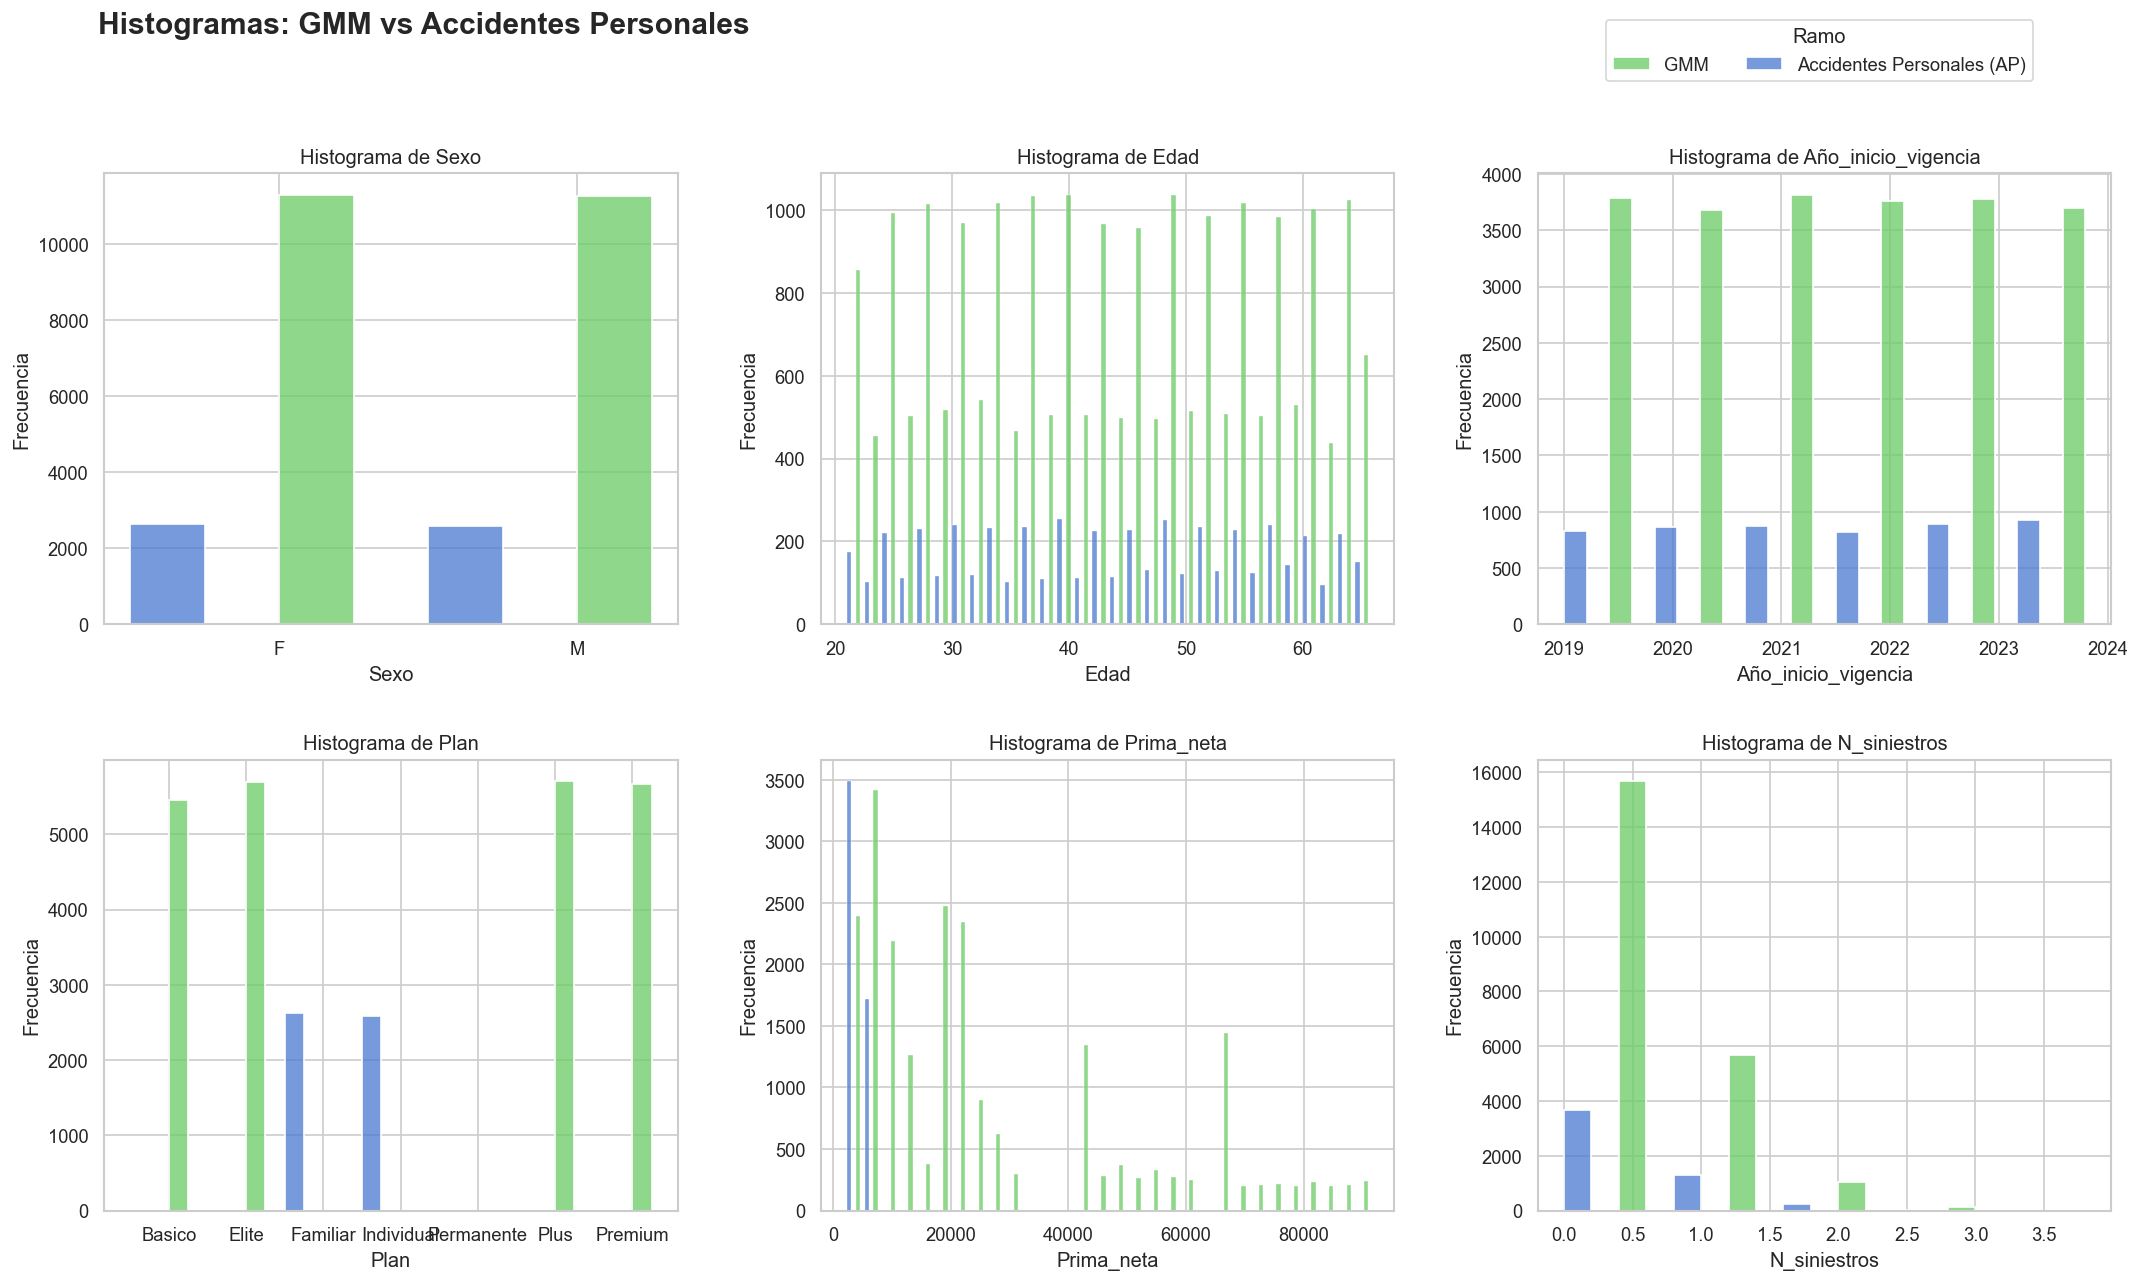

In [200]:
# 2. Obtener los histogramas de las variables: sexo, edad, año de inicio de vigencia, plan, primas y siniestros. 

# 2.1. Filtrar los datos de los ramos de interés
subramos_interes = ["GMM", "Accidentes Personales"]
df_filtrado = df[(df["ramo"].isin(subramos_interes))]

# 2.2 Crear una figura con 2 filas y 3 columnas para acomodar los histogramas
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()  # Volver los ejes una lista plana de 6 elementos

# 2.3. Definimos las variables a graficar
# Obtenemos el año de inici de vigencia
df_filtrado["Año_inicio_vigencia"] = df_filtrado['fecha_inicio_vigencia'].dt.year
# Lista de variables a recorrer
variables = [
    "sexo",
    "edad",
    "Año_inicio_vigencia",
    "plan",
    "prima_neta",
    "n_siniestros",
]

# 2.4. Iteramos sobre las variables y los ejes para crear los gráficos correspondientes
for i, var in enumerate(variables):
    # Trabajamos sobre el eje correspondiente
    ax = axes[i]  
    
    # Si la variable es categórica, hacemos un grafico de barras
    if df_filtrado[var].dtype == "object":
        sns.countplot(
            x=var, 
            hue="ramo",  # Diferenciamos por ramo usando el argumento hue
            data=df_filtrado, 
            ax=ax,
            dodge=True, # Para separar las barras de cada categoría por ramo
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Distribución de {var.capitalize()}")
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
        # Añadir etiquetas de datos
    # Si la variable es numérica, hacemos un histograma
    else:
        # Calcular los bins automáticamente para variables numéricas/discretas
        bins_choise = (
            len(df_filtrado[var].unique())
            if "año" in var or "fecha" in var or df_filtrado[var].nunique() < 10
            else 30
        )
        sns.histplot(
            data=df_filtrado, 
            x=var, 
            hue="ramo", # Diferenciamos por ramo usando el argumento hue
            bins=bins_choise, 
            ax=ax, 
            multiple="dodge", # Para separar las barras de cada categoría por ramo
            common_norm=False
        )
        # Ajustamos títulos y etiquetas
        ax.set_title(f"Histograma de {var.capitalize()}")
        ax.set_xlabel(var.capitalize())
        ax.set_ylabel("Frecuencia")
    
    # Quitamos la leyenda individual de cada gráfico para que no estorbe
    if ax.get_legend():
        ax.get_legend().remove()

# --- 4. LEYENDA GLOBAL Y TÍTULO ---
etiquetas_personalizadas = ["GMM","Accidentes Personales (AP)"]

fig.legend( etiquetas_personalizadas, loc='upper right', bbox_to_anchor=(0.95, 0.97), 
           ncol=2, fontsize=11, title="Ramo", frameon=True)

fig.suptitle("Histogramas: GMM vs Accidentes Personales", 
             fontsize=18, fontweight='bold', x=0.05, ha='left', y=0.97)

# MEJORA: Ajustamos los espacios entre los cuadros (h_space = espacio vertical, w_space = horizontal)
# para asegurarnos de que las etiquetas del eje X y títulos no se encimen.
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(wspace=0.25, hspace=0.3) 

plt.show()

En general veo que los histogramas son similares en ambos ramos:

- **Sexo:** Ambas carteras presentan una distribución equilibrada (cercana al 50/50) entre hombres y mujeres.
- **Edad:** La distribución de la edad es uniforme y estable a lo largo del rango laboral y adulto (aproximadamente de los 20 a los 65 años) en ambos productos. La diferencia visual en la altura de las barras se debe exclusivamente al tamaño de la muestra (GMM posee un volumen de pólizas con siniestro significativamente mayor).
- **Año inicio de vigencia:** Las carteras muestran un comportamiento estable y constante a lo largo del tiempo, sin embargo, se observa que en 2024 AP alcanzó su punto máximo de frecuencia y GMM decrecé respecto a años anteriores.
- **Plan:** Ambas carteras concentras sus polizas de forma equitativa en sus respectivas categorias, esto indica que la cartera está diversificada.
- **Prima Neta:** AP tiene una cartera concentrada en primas de muy bajo costo y GGM muestra una cola pesada que sobrepasa los $80,000.
- **Número de Siniestros:** Ambos ramos muestran que las pérdidas se concentran en una cantidad mínima de eventos por póliza.

In [201]:
# 3.	Codifica las variables que consideres necesario. Explica por qué consideraste esas variables y que tipo de codificación aplicaste.

# 3.1 One-Hot Encoding — pocas categorías, sin orden natural
# Estoy codificando las variables 'sexo', 'ramo' y 'plan' porque son categóricas con pocas categorías y no tienen un orden natural.
dummies_sexo = pd.get_dummies(df['sexo'], prefix='sexo', drop_first=True, dtype=int)
dummies_ramo = pd.get_dummies(df['ramo'], prefix='ramo', drop_first=True, dtype=int)
dummies_plan = pd.get_dummies(df['plan'], prefix='plan', drop_first=True, dtype=int)

df = pd.concat(
    [df, dummies_sexo, dummies_ramo, dummies_plan],
    axis=1
)


# 3.2 Label Encoding — variables ordinales o con muchas categorías  
# No estoy aplicando label encoding, ya que, no identifico variables con orden real

# 3.3 Target Encoding — para variables con alta cardinalidad y relación con la variable objetivo
# Se le aplica target encoding a las variables estado y municipio y puede ser útil para ver la relacion con la variables monto_pagado.
# Calcular el promedio de monto_pagado para cada categoría de estado y municipio
target_mean_estado = df.groupby('estado')['monto_pagado'].mean()
target_mean_municipio = df.groupby('municipio')['monto_pagado'].mean()
# Mapear los promedios a las nuevas columnas
df['estado_target_enc'] = df['estado'].map(target_mean_estado)
df['municipio_target_enc'] = df['municipio'].map(target_mean_municipio)
df.head(3)


,id_poliza,num_poliza,nombre,apellido_paterno,apellido_materno,rfc,edad,sexo,estado_civil,ocupacion,...,plan_Basico,plan_Elite,plan_Familiar,plan_Individual,plan_Permanente,plan_Plus,plan_Premium,plan_RC+LT,estado_target_enc,municipio_target_enc
0,POL-000001,Vid-21-000001,Gabriela,Moreno,Vega,MOGV020429CG6,24,F,Union libre,Independiente,...,0,0,0,0,0,0,0,0,"4,361.32","4,456.09"
1,POL-000002,Aut-19-000002,Valeria,Torres,Castillo,TOVC020815IA8,23,F,Casado,Contador,...,0,0,0,0,0,0,0,0,"4,322.43","3,927.44"
2,POL-000003,GMM-22-000003,Fernanda,Ramos,Silva,RAFS941018BC1,31,M,Union libre,Ingeniero,...,1,0,0,0,0,0,0,0,"4,319.74","4,864.06"


In [202]:
# 4.Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?
# Empiezo el analisis con GMM y con los registros con monto_pagado > 0 para que el análisis de escalamiento de siniestralidad tenga sentido
df_filtrado_GMM = df[(df['ramo'] == 'GMM') & (df['monto_pagado'] > 0)]
variables_escalamiento = ['prima_neta', 'monto_pagado', 'n_siniestros']

# Definimos los escaladores a aplicar
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

# Diccionario para almacenar los resultados de las estadísticas descriptivas de las variables escaladas
resultados_scaling = {}

# Aplicamos cada escalador a las variables seleccionadas y almacenamos los resultados en un nuevo dataframe
for nombre, scaler in scalers.items():
    datos_escalar = df_filtrado_GMM[variables_escalamiento]
    datos_escalados = scaler.fit_transform(datos_escalar)
    resultados_scaling[nombre] = pd.DataFrame(datos_escalados, columns=variables_escalamiento)
    
# Calculamos las estadísticas descriptivas para cada tipo de escalamiento

for variable in variables_escalamiento:
    print("=" * 70)
    print(' '*10 +f"TABLA COMPARATIVA: {variable} después de escalar")
    print("=" * 70)
    print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 70)
    
    # 1. Estadísticas de los datos originales
    original_mean = df_filtrado_GMM[variable].mean()
    original_std  = df_filtrado_GMM[variable].std()
    original_min  = df_filtrado_GMM[variable].min()
    original_max  = df_filtrado_GMM[variable].max()
    print(f"{'Original':<25} {original_mean:>10.2f} {original_std:>10.2f} {original_min:>10.2f} {original_max:>10.2f}")
    
    # 2. Estadísticas de cada método de escalado
    for nombre, df_escalado in resultados_scaling.items():
        s = df_escalado[variable]
        print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")
    print("\n")

          TABLA COMPARATIVA: prima_neta después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                    26386.97   23309.49    4400.00   91740.00
Min-Max Scaler                0.2517     0.2669     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0002    -0.9434     2.8042
Robust Scaler                 0.2367     0.6472    -0.3739     2.0513


          TABLA COMPARATIVA: monto_pagado después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                    34451.58   48622.00      49.10  698744.32
Min-Max Scaler                0.0492     0.0696     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0002    -0.7077    13.6648
Robust Scaler                 0.4497     1.4510    -0.5769    20.2741


          TABLA COMPARATIVA: n_sin

### GMM

- **Prima Neta:** El costo de las pólizas en GMM va desde un minimo de $4,400 hasta un máximo de $91,740 y con una media de $26,386. El máximo está a menos de 3 desviaciones estándar de la media
    - En este caso prefiero el Robust Scaler, ya que, como vimos en los histogramas la prima en GMM no tiene un comportamiento normal por lo que descartaria el Z-score. Por otro lado Min-Max Scaler disminuye mucho el máximo lo que puede hacer menos sensible los datos para identificar variaciones.

- **Monto Pagado:** El mínimo es de 49.10, pero tiene un siniestro catastrofico de $698,744, mientras que la media es de apenas de $34,451. Sin embargo, la desviación estándar es muy grande, lo que nos indica que es una distribución con cola derecha pesada.
    - El robust Scaler es la mejor opción, dado a su tolerancia con los outliers, en este caso el Z-score se queda corto, ya que el máximo está a aproximadamente a 13 desviaciones estándar y el Min-Max Scales es inadecuado por los outliers.
- **Número de Siniestros:** El mínimo es de 1 y el máximo es de 4, con una media de 1.29.
    - Min-Max Scaler es el más adecuado debido al rango pequeño de la variable.


In [203]:
# 4.Aplicar los 3 tipos de escalamiento a primas y siniestros. Obtén sus estadísticas y compáralas con las originales. ¿Qué concluyes?
df_filtrado_AP = df[(df['ramo'] == 'Accidentes Personales') & (df['monto_pagado'] > 0)]
variables_escalamiento = ['prima_neta', 'monto_pagado', 'n_siniestros']

# Definimos los escaladores a aplicar
scalers = {
    'Min-Max Scaler':   MinMaxScaler(),
    'Z-Score (Standard)': StandardScaler(),
    'Robust Scaler':    RobustScaler()
}

# Diccionario para almacenar los resultados de las estadísticas descriptivas de las variables escaladas
resultados_scaling = {}

# Aplicamos cada escalador a las variables seleccionadas y almacenamos los resultados en un nuevo dataframe
for nombre, scaler in scalers.items():
    datos_escalar = df_filtrado_AP[variables_escalamiento]
    datos_escalados = scaler.fit_transform(datos_escalar)
    resultados_scaling[nombre] = pd.DataFrame(datos_escalados, columns=variables_escalamiento)
    
# Calculamos las estadísticas descriptivas para cada tipo de escalamiento

for variable in variables_escalamiento:
    print("=" * 70)
    print(' '*10 +f"TABLA COMPARATIVA: {variable} después de escalar")
    print("=" * 70)
    print(f"{'Método':<25} {'Media':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
    print("-" * 70)
    
    # 1. Estadísticas de los datos originales
    original_mean = df_filtrado_AP[variable].mean()
    original_std  = df_filtrado_AP[variable].std()
    original_min  = df_filtrado_AP[variable].min()
    original_max  = df_filtrado_AP[variable].max()
    print(f"{'Original':<25} {original_mean:>10.2f} {original_std:>10.2f} {original_min:>10.2f} {original_max:>10.2f}")
    
    # 2. Estadísticas de cada método de escalado
    for nombre, df_escalado in resultados_scaling.items():
        s = df_escalado[variable]
        print(f"{nombre:<25} {s.mean():>10.4f} {s.std():>10.4f} {s.min():>10.4f} {s.max():>10.4f}")
    print("\n")



          TABLA COMPARATIVA: prima_neta después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                     3965.97    1479.94    2400.00    6000.00
Min-Max Scaler                0.4350     0.4111     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0008    -1.0590     1.3755
Robust Scaler                 0.1017     0.4111    -0.3333     0.6667


          TABLA COMPARATIVA: monto_pagado después de escalar
Método                         Media        Std        Min        Max
----------------------------------------------------------------------
Original                    35812.84   66510.39      42.60 1067933.83
Min-Max Scaler                0.0335     0.0623     0.0000     1.0000
Z-Score (Standard)           -0.0000     1.0008    -0.5382    15.5307
Robust Scaler                 0.5446     2.1248    -0.5982    33.5171


          TABLA COMPARATIVA: n_sin

### AP

- **Prima Neta:** El costo de las pólizas en AP es bajo y concentrado, el minimo es de $2,400 y el máximo de $6,000, con una media de $3,966. Además, de acuerdo a la desviación estándar no hay outliers.
    - En este caso Z-Score y Min-Max Scaler pueden ser una buena opción para escalar, debido a la ausencia de outliers y como podemos ver con el resumen estadistico, se preserva la estructura de los datos.

- **Monto Pagado:** El mínimo es de 42.60, pero tiene un siniestro catastrofico de $1,067,933, mientras que la media es de apenas de $35,812. Sin embargo, la desviación estándar es muy grande, lo que nos indica que es una distribución con cola derecha pesada.
    - El robust Scaler es la mejor opción, dado a su tolerancia con los outliers, en este caso el Z-score se queda corto, ya que el máximo está a aproximadamente a 15 desviaciones estándar y el Min-Max Scaler es inadecuado por los outliers.
- **Número de Siniestros:** El mínimo es de 1 y el máximo es de 4, con una media de 1.29.
    - Min-Max Scaler es el más adecuado debido al rango pequeño de la variable.


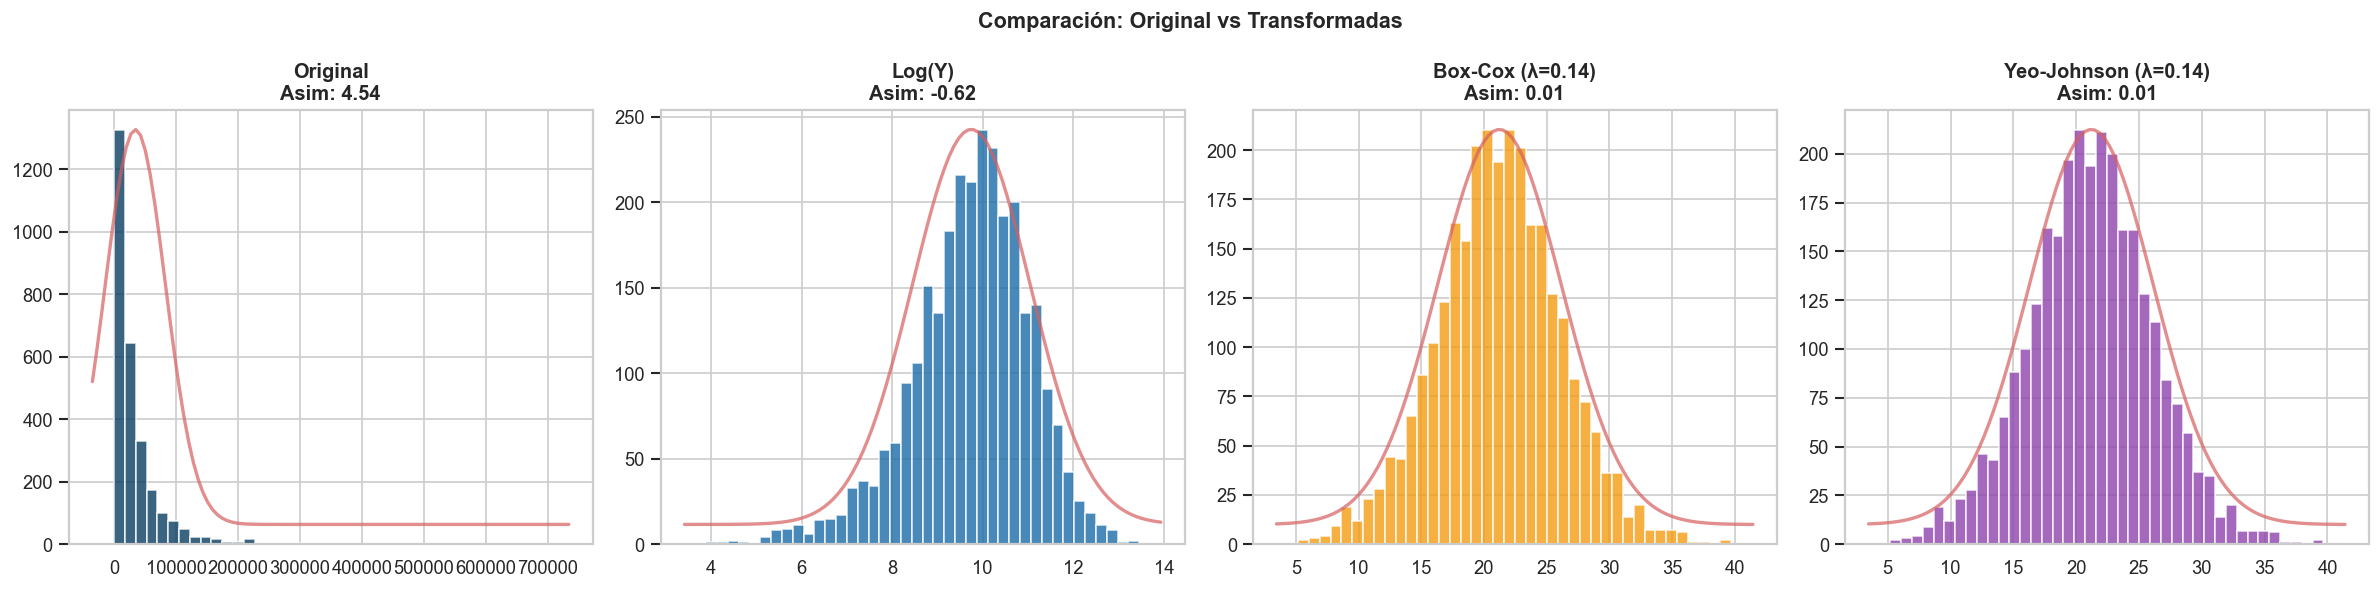

Conclusión Gastos Médicos:
La variable 'monto_pagado' presenta una alta asimetría positiva, lo que sugiere la presencia de valores atípicos o una distribución sesgada.
Las transformaciones Box-Cox y Yeo-Johnson son los que reducen más la asimetría y las que más se acercan a una distribución normal.


In [204]:
# 5.Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.

# GMM
y = df_filtrado_GMM['monto_pagado']
y_boxcox_GMM, lambda_optimo_GMM = boxcox(y)
y_yj_GMM, lambda_yj_GMM = yeojohnson(y)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox_GMM, y_yj_GMM]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo_GMM:.2f})\nAsim: {stats.skew(y_boxcox_GMM):.2f}',
          f'Yeo-Johnson (λ={lambda_yj_GMM:.2f})\nAsim: {stats.skew(y_yj_GMM):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxcox_transform.png', dpi=120, bbox_inches='tight')
plt.show()

print("Conclusión Gastos Médicos:")
print("La variable 'monto_pagado' presenta una alta asimetría positiva, lo que sugiere la presencia de valores atípicos o una distribución sesgada.")
print("Las transformaciones Box-Cox y Yeo-Johnson son los que reducen más la asimetría y las que más se acercan a una distribución normal.")


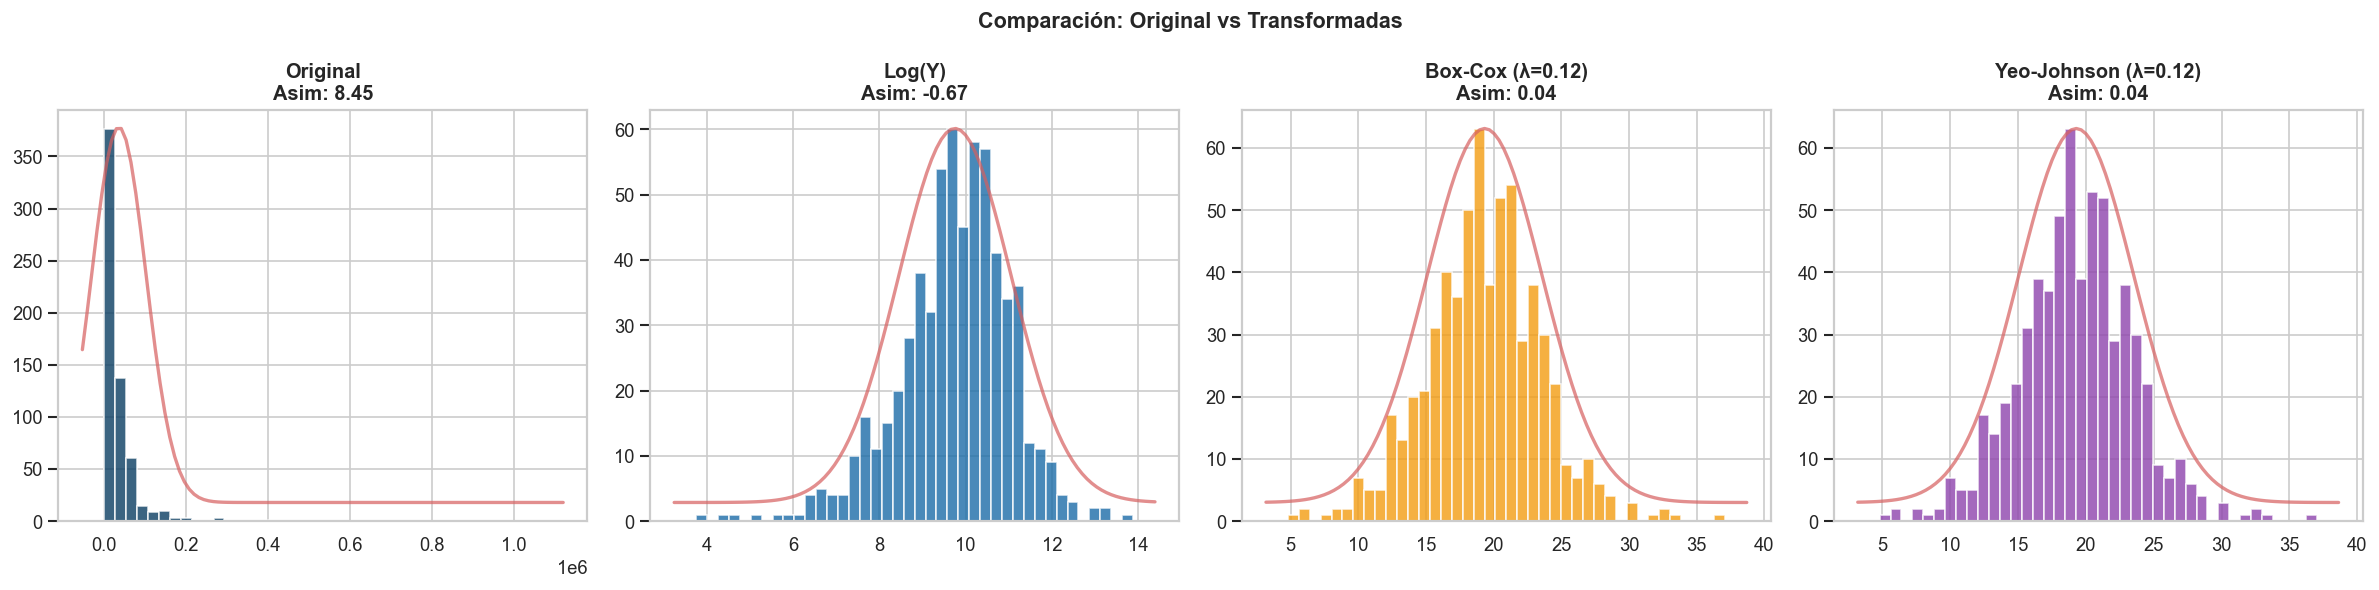

Conclusión Accidentes personales:
La variable 'monto_pagado' presenta una alta asimetría positiva, lo que sugiere la presencia de valores atípicos o una distribución sesgada.
Las transformaciones Box-Cox y Yeo-Johnson son los que reducen más la asimetría y las que más se acercan a una distribución normal.


In [205]:
# 5.Haz la transformación Box-Cox, logarítmica y Yeo-Johnson al monto del siniestro. Haz un histograma de la serie original y cada una de las transformaciones. Agrega la distribución normal.
# AP
y = df_filtrado_AP['monto_pagado']
y_boxcox_AP, lambda_optimo_AP = boxcox(y)
y_yj_AP, lambda_yj_AP = yeojohnson(y)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
datos = [y, np.log(y), y_boxcox_AP, y_yj_AP]
labels = [f'Original\nAsim: {stats.skew(y):.2f}',
          f'Log(Y)\nAsim: {stats.skew(np.log(y)):.2f}',
          f'Box-Cox (λ={lambda_optimo_AP:.2f})\nAsim: {stats.skew(y_boxcox_AP):.2f}',
          f'Yeo-Johnson (λ={lambda_yj_AP:.2f})\nAsim: {stats.skew(y_yj_AP):.2f}',]
colors = ['#0A3D62', '#1B6CA8', '#F39C12', '#8E44AD']

for ax, d, lab, c in zip(axes, datos, labels, colors):
    ax.hist(d, bins=40, color=c, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    # Agregar curva normal teórica
    xmin, xmax = ax.get_xlim()
    x_norm = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x_norm, d.mean(), d.std())
    ax_twin = ax.twinx()
    ax_twin.plot(x_norm, p, 'r-', linewidth=2, alpha=0.7, label='Normal')
    ax_twin.set_ylabel('')
    ax_twin.set_yticks([])

plt.suptitle('Comparación: Original vs Transformadas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxcox_transform.png', dpi=120, bbox_inches='tight')
plt.show()
print("Conclusión Accidentes personales:")
print("La variable 'monto_pagado' presenta una alta asimetría positiva, lo que sugiere la presencia de valores atípicos o una distribución sesgada.")
print("Las transformaciones Box-Cox y Yeo-Johnson son los que reducen más la asimetría y las que más se acercan a una distribución normal.")

In [206]:
def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.6382 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9964 | p-valor: 0.326619 | ✅ Normal
Log(Y+1)        | Estadístico: 0.9723 | p-valor: 0.000000 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.9964 | p-valor: 0.327042 | ✅ Normal


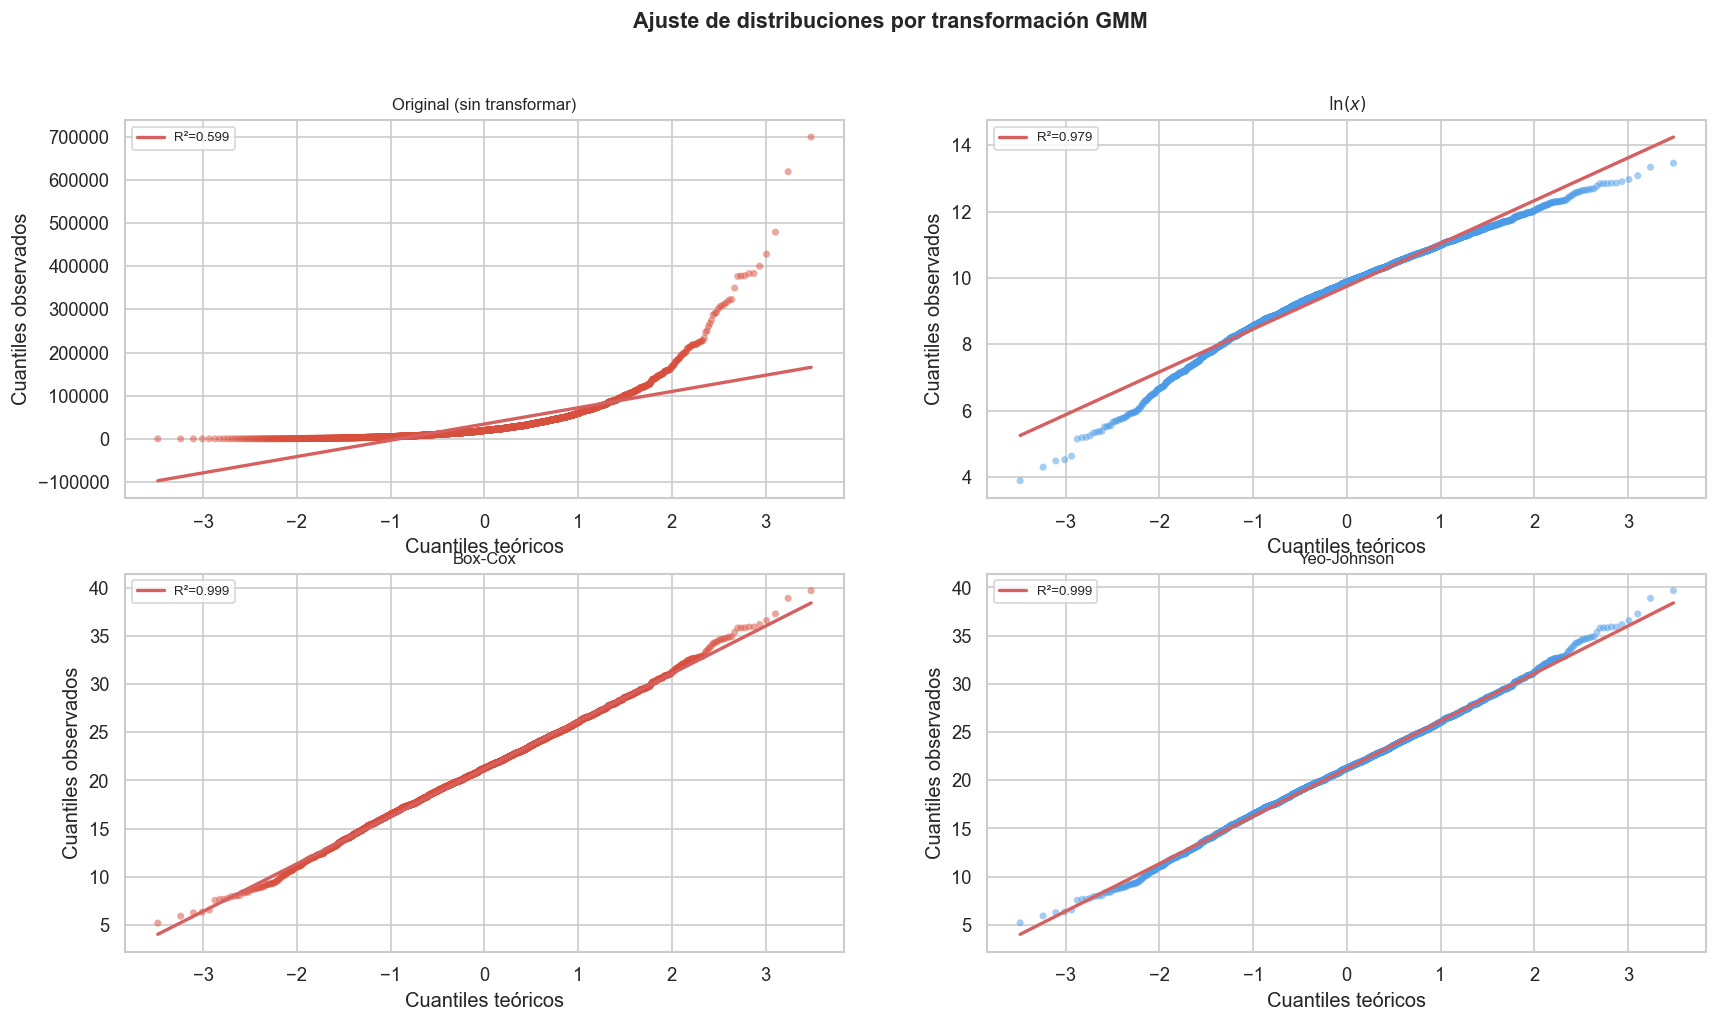

In [207]:
# 6.Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?
# GMM 
# Hacemos los Q-Q plot para la serie original y cada transformación, y realizamos la prueba de normalidad de Shapiro-Wilk

# Cramos una figura de 2x2 para mostrar los QQ-plots de cada escala.
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
# Titulo general del gráfico
fig.suptitle('Ajuste de distribuciones por transformación GMM',
             fontsize=13, fontweight='bold')
# Definimos las configuraciones para cada escala: nombre de la columna, título del gráfico y color.
configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('Log',        '$\\ln(x)$',                 '#4C9BE8'),
    ('Box-Cox',     'Box-Cox', '#D94F3D'),
    ('Yeo-Johnson',         'Yeo-Johnson',     '#4C9BE8'),
]

transf = pd.DataFrame({
    'original'     : df_filtrado_GMM['monto_pagado'],
    'Log'         : np.log(df_filtrado_GMM['monto_pagado']),        
    'Box-Cox'      : y_boxcox_GMM,
    'Yeo-Johnson'      : y_yj_GMM         # referencia clásica
})

# Iteramos sobre cada entrada de configuración y el eje correspondiente para crear los QQ-plots.
axes_flat = axes.flat
# La función qqplot_ax es la que definimos antes para crear un QQ-plot en un eje dado.
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

variables_test = {
    'Original': df_filtrado_GMM['monto_pagado'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox_GMM).sample(500, random_state=70),
    'Log(Y+1)': pd.Series(np.log(df_filtrado_GMM['monto_pagado'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj_GMM).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

### CONCLUSIONES

Con las tranformaciones Box-Cox y Yeo-Johnson los montos pagados en GMM se ajustan a una distribución normal y se puede verificar con la prueba de shapiro y los Q-Q plot

TEST DE NORMALIDAD (Shapiro-Wilk)
H0: Los datos siguen distribución normal
Si p-valor > 0.05 → No rechazamos normalidad
Original        | Estadístico: 0.5370 | p-valor: 0.000000 | ❌ No normal
Box-Cox         | Estadístico: 0.9959 | p-valor: 0.213126 | ✅ Normal
Log(Y+1)        | Estadístico: 0.9798 | p-valor: 0.000002 | ❌ No normal
Yeo-Johnson     | Estadístico: 0.9959 | p-valor: 0.216004 | ✅ Normal


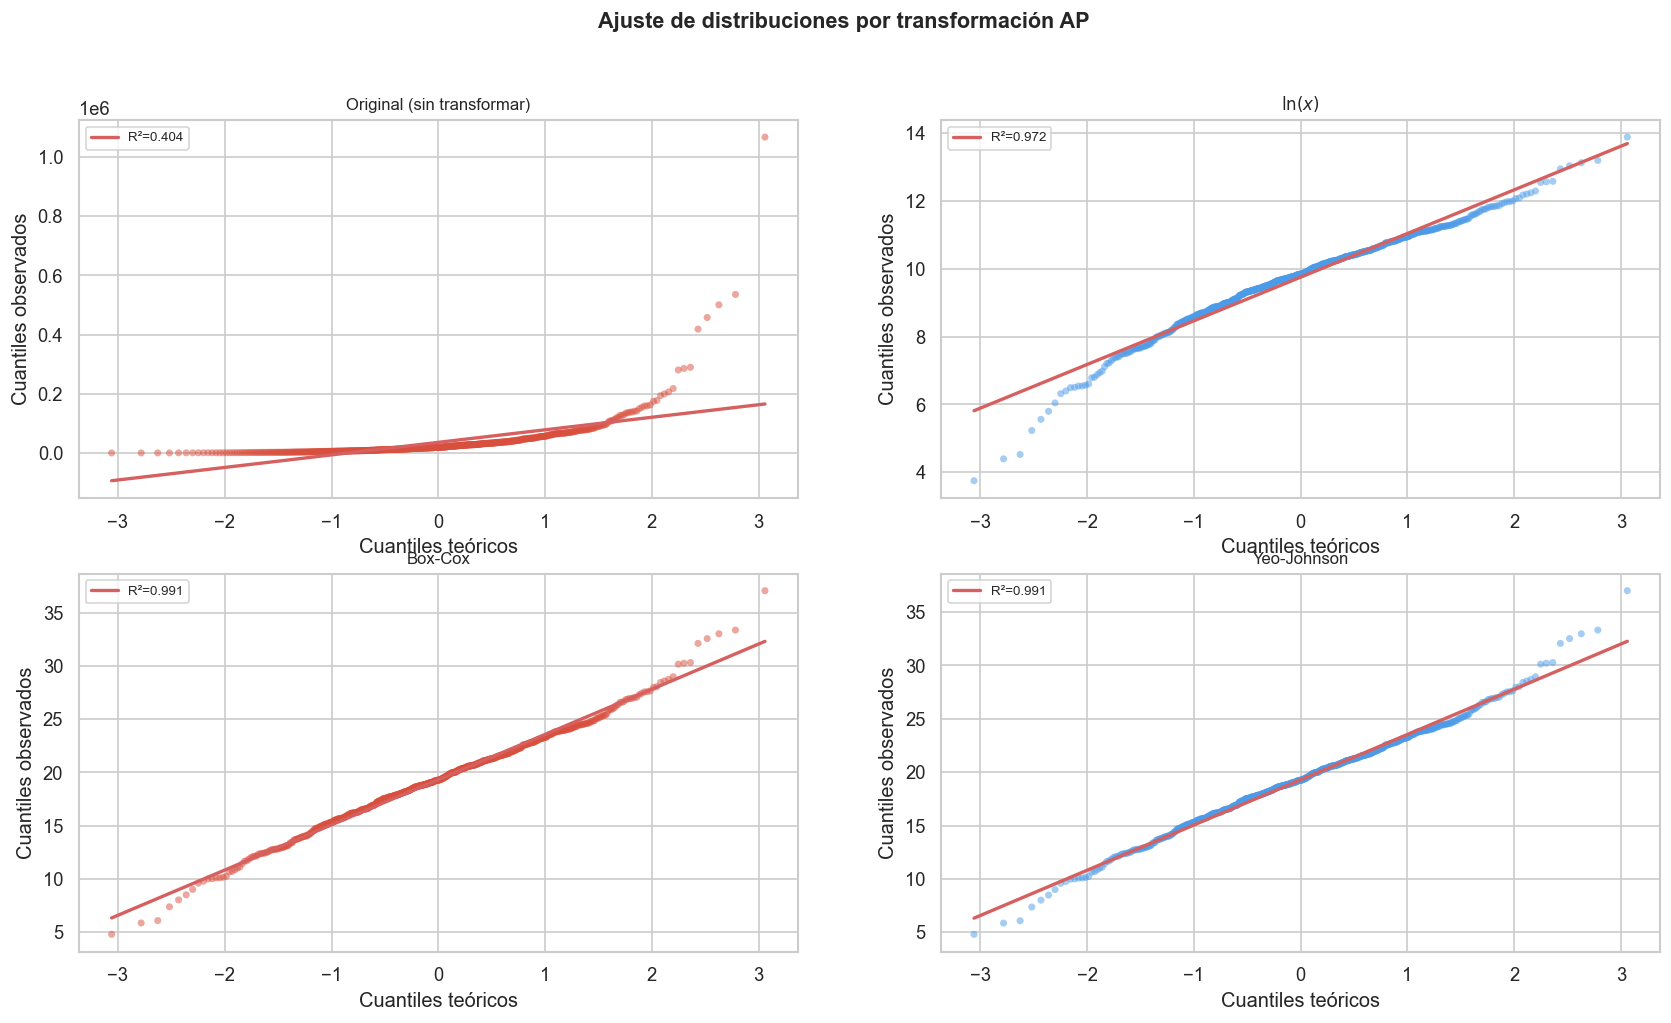

In [208]:
# 6.Crea el Q-Q plot para la serie original y cada transformación, haz la prueba de hipótesis de normalidad. ¿Qué concluyes?
# AP
# Hacemos los Q-Q plot para la serie original y cada transformación, y realizamos la prueba de normalidad de Shapiro-Wilk

# Cramos una figura de 2x2 para mostrar los QQ-plots de cada escala.
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
# Titulo general del gráfico
fig.suptitle('Ajuste de distribuciones por transformación AP',
             fontsize=13, fontweight='bold')
# Definimos las configuraciones para cada escala: nombre de la columna, título del gráfico y color.
configs = [
    ('original',    'Original (sin transformar)',  '#D94F3D'),
    ('Log',        '$\\ln(x)$',                 '#4C9BE8'),
    ('Box-Cox',     'Box-Cox', '#D94F3D'),
    ('Yeo-Johnson',         'Yeo-Johnson',     '#4C9BE8'),
]

transf = pd.DataFrame({
    'original'     : df_filtrado_AP['monto_pagado'],
    'Log'         : np.log(df_filtrado_AP['monto_pagado']),        
    'Box-Cox'      : y_boxcox_AP,
    'Yeo-Johnson'      : y_yj_AP         # referencia clásica
})

# Iteramos sobre cada entrada de configuración y el eje correspondiente para crear los QQ-plots.
axes_flat = axes.flat
# La función qqplot_ax es la que definimos antes para crear un QQ-plot en un eje dado.
for (col, titulo, color), ax in zip(configs, axes_flat):
    qqplot_ax(ax, transf[col], titulo, color)

variables_test = {
    'Original': df_filtrado_AP['monto_pagado'].sample(500, random_state=70),
    'Box-Cox': pd.Series(y_boxcox_AP).sample(500, random_state=70),
    'Log(Y+1)': pd.Series(np.log(df_filtrado_AP['monto_pagado'])).sample(500, random_state=70),
    'Yeo-Johnson': pd.Series(y_yj_AP).sample(500, random_state=70),
}

print("=" * 55)
print("TEST DE NORMALIDAD (Shapiro-Wilk)")
print("H0: Los datos siguen distribución normal")
print("Si p-valor > 0.05 → No rechazamos normalidad")
print("=" * 55)

for nombre, data in variables_test.items():
    stat, p_valor = shapiro(data)
    decision = "✅ Normal" if p_valor > 0.05 else "❌ No normal"
    print(f"{nombre:15s} | Estadístico: {stat:.4f} | p-valor: {p_valor:.6f} | {decision}")

### CONCLUSIONES

Con las tranformaciones Box-Cox y Yeo-Johnson los montos pagados en AP se ajustan a una distribución normal y se puede verificar con la prueba de shapiro y los Q-Q plot

In [ ]:
# 7. Calcula las siguientes variables derivadas: mayor de 65 años, Siniestros altos (se definen como los montos pagados mayores a $25,000 en accidentes personales y mayores a $200,000 en gastos médicos).
#  ¿Cuántos siniestros cumplen estas características y qué % del total de siniestros representan?
df_GMM = df[df['ramo'] == 'GMM']

# Creamos las variables derivadas para ambos ramos
df_GMM['mayor_65'] = (df_GMM['edad'] > 65).astype(int)
df_GMM['siniestro_alto'] = np.where( df_GMM['monto_pagado'] > 200_000,
        1,
        0
)

# Calculamos el número de siniestros altos y su porcentaje respecto al total
total_siniestros = df_GMM['n_siniestros'].sum()
siniestros_altos = df_GMM['siniestro_alto'].sum()
porcentaje_siniestros_altos = (siniestros_altos / total_siniestros) * 100

print(f"Número de siniestros altos: {siniestros_altos}")
print(f"Porcentaje de siniestros altos respecto al total: {porcentaje_siniestros_altos:.2f}%")

Número de siniestros altos: 45
Porcentaje de siniestros altos respecto al total: 0.55%


In [211]:
df_AP = df[df['ramo'] == 'Accidentes Personales']

# Creamos las variables derivadas para ambos ramos
df_AP['mayor_65'] = (df_AP['edad'] > 65).astype(int)
df_AP['siniestro_alto'] = np.where( df_AP['monto_pagado'] > 25_000,
        1,
        0
)

# Calculamos el número de siniestros altos y su porcentaje respecto al total
total_siniestros = df_AP['n_siniestros'].sum()
siniestros_altos = df_AP['siniestro_alto'].sum()
porcentaje_siniestros_altos = (siniestros_altos / total_siniestros) * 100

print(f"Número de siniestros altos: {siniestros_altos}")
print(f"Porcentaje de siniestros altos respecto al total: {porcentaje_siniestros_altos:.2f}%")

Número de siniestros altos: 263
Porcentaje de siniestros altos respecto al total: 14.35%


In [212]:
# 8.	Calcula la media del siniestro por sexo, año de inicio de vigencia y plan.

# GMM
df_GMM['Año_inicio_vigencia'] = df_GMM['fecha_inicio_vigencia'].dt.year
media_siniestro_GMM = df_GMM.groupby(['sexo', 'Año_inicio_vigencia', 'plan'], observed=True)['monto_pagado'].mean().reset_index()
print(media_siniestro_GMM.head(10))

  sexo  Año_inicio_vigencia     plan  monto_pagado
0    F                 2019   Basico      4,377.62
1    F                 2019    Elite      4,463.78
2    F                 2019     Plus      3,402.67
3    F                 2019  Premium      3,271.07
4    F                 2020   Basico      3,628.59
5    F                 2020    Elite      4,449.89
6    F                 2020     Plus      5,238.18
7    F                 2020  Premium      6,359.52
8    F                 2021   Basico      4,376.31
9    F                 2021    Elite      4,433.81


In [213]:
df_AP['Año_inicio_vigencia'] = df_AP['fecha_inicio_vigencia'].dt.year
media_siniestro_AP = df_AP.groupby(['sexo', 'Año_inicio_vigencia', 'plan'], observed=True)['monto_pagado'].mean().reset_index()
print(media_siniestro_AP.head(10))

  sexo  Año_inicio_vigencia        plan  monto_pagado
0    F                 2019    Familiar      2,763.16
1    F                 2019  Individual      4,692.57
2    F                 2020    Familiar      7,705.87
3    F                 2020  Individual      3,293.99
4    F                 2021    Familiar      5,678.69
5    F                 2021  Individual      7,491.11
6    F                 2022    Familiar      4,417.03
7    F                 2022  Individual      6,883.84
8    F                 2023    Familiar      3,558.01
9    F                 2023  Individual      5,160.71
